# 🌱 Análisis de Cambios de Vegetación con Sentinel-2 (La Palma, 2021)

Este notebook muestra cómo detectar **cambios de vegetación** antes y después de la **erupción volcánica de Cumbre Vieja (Islas Canarias, 2021)** utilizando datos **Sentinel-2 L2A** del programa **Copernicus**.

Aprenderás a:
1. Descargar imágenes Sentinel-2 mediante la API de Sentinel Hub.
2. Calcular el índice NDVI.
3. Visualizar el cambio de vegetación (ΔNDVI) entre dos fechas.
4. Medir hasta dónde llega el efecto del volcán y cuántas hectáreas de vegetación se perdieron.
5. Seguir la evolución mes a mes, combinando varias imágenes para evitar las nubes.


## 🔑 1. Configuración de credenciales

Las imágenes se descargan desde **Copernicus Data Space Ecosystem (CDSE)**, la plataforma oficial y **gratuita** del programa Copernicus (Agencia Espacial Europea y Comisión Europea). La librería `sentinelhub` se conecta a su API para buscar y descargar imágenes Sentinel-2.

Para usarla necesitás dos datos: un **Client ID** y un **Client Secret**. Funcionan como un usuario y una contraseña para que tu código (no vos) se conecte a la API. Seguí estos pasos una sola vez.

### Paso A: Crear tu cuenta en Copernicus Data Space

1. Entrá a [https://dataspace.copernicus.eu](https://dataspace.copernicus.eu) y hacé clic en **Login** (arriba a la derecha).
2. En la pantalla de inicio de sesión, elegí **Register** para crear una cuenta nueva.
3. Completá el formulario (nombre, email, país, contraseña, etc.) y aceptá los términos.
4. Vas a recibir un **email de verificación**: abrilo y confirmá tu cuenta. Si no llega en unos minutos, revisá la carpeta de spam.

> Si ya tenés cuenta en Copernicus (por ejemplo, del Paso 1 del notebook de clase), usá esa misma y saltá al Paso B.

### Paso B: Generar el Client ID y el Client Secret

1. Entrá al **Sentinel Hub Dashboard de CDSE**: [https://shapps.dataspace.copernicus.eu/dashboard/](https://shapps.dataspace.copernicus.eu/dashboard/) e iniciá sesión con la cuenta del Paso A.
2. Abrí la pestaña **User Settings**.
3. Buscá la sección **OAuth clients** y hacé clic en **Create**.
4. Completá el formulario:
   - **Name**: un nombre que te sirva para reconocerlo, por ejemplo `taller-ndvi`.
   - **Expiry date**: elegí una fecha posterior al final del taller, o **Never expire**.
   - **No** marques la opción de *single-page application (SPA)*: no la necesitamos.
5. Hacé clic en **Create**.
6. ⚠️ **Copiá en ese momento el Client ID y el Client Secret** y guardalos en un lugar seguro (por ejemplo, un gestor de contraseñas). **El secret se muestra una sola vez.** Si lo perdés, no se puede recuperar: borrá ese cliente y creá otro.

### Paso C: Darle las credenciales al notebook

**Nunca escribas tus credenciales dentro del notebook.** Si lo compartís o lo subís a GitHub, cualquiera podría usarlas. Tenés dos opciones:

**Opción 1: variables de entorno (recomendada).** Las variables de entorno se definen en una terminal del sistema (en macOS, la app *Terminal*; en Windows, *PowerShell*), **no en una celda del notebook**. El programa que abras después desde esa misma terminal las recibe.

1. Abrí una terminal y andá a la carpeta del taller:
   ```bash
   cd ruta/a/la/carpeta/del/taller
   ```
2. Si usás un entorno de Python (conda, venv), activalo. Por ejemplo, con conda:
   ```bash
   conda activate nombre-de-tu-entorno
   ```
3. Definí las credenciales:
   - macOS / Linux:
     ```bash
     export SH_CLIENT_ID="tu-client-id"
     export SH_CLIENT_SECRET="tu-client-secret"
     ```
   - Windows (PowerShell):
     ```powershell
     $env:SH_CLIENT_ID="tu-client-id"
     $env:SH_CLIENT_SECRET="tu-client-secret"
     ```
4. Desde **esa misma terminal**, abrí el programa con el que trabajás:
   - **JupyterLab**: `jupyter lab`
   - **Jupyter Notebook**: `jupyter notebook`
   - **VS Code**: `code .` (antes cerrá VS Code por completo, con Cmd + Q en macOS o *File → Exit* en Windows; si ya estaba abierto, no recibe las variables).

   Si aparece `command not found`, el programa no está instalado en ese entorno o el entorno no está activado (paso 2).

Las variables duran mientras esa terminal esté abierta: podés reiniciar el kernel sin perderlas. Si cerrás la terminal, la próxima vez repetí los pasos 1 a 4.

**Opción 2: escribirlas cuando el notebook las pida.** Si no definiste las variables (por ejemplo, en Google Colab), la celda siguiente te va a pedir el Client ID y el Client Secret en un cuadro de texto. Lo que escribas no se muestra ni se guarda en el notebook. Vas a tener que volver a escribirlas cada vez que reinicies el kernel.

### Paso D: Comprobar que funcionan

Ejecutá la celda siguiente. Al final verifica las credenciales contra Copernicus:

- ✅ `Credenciales válidas` → listo, seguí con la sección 2.
- ❌ `Credenciales inválidas` → revisá que hayas copiado el ID y el secret completos y sin espacios, y que el cliente no haya vencido. Si el secret se perdió, creá un cliente nuevo (Paso B).

In [1]:
import os
from getpass import getpass
from sentinelhub import SHConfig, DataCollection, SentinelHubSession

# Las credenciales se leen de variables de entorno; si no existen, se piden por pantalla.
config = SHConfig()
config.sh_client_id = os.environ.get("SH_CLIENT_ID") or getpass("Client ID: ")
config.sh_client_secret = os.environ.get("SH_CLIENT_SECRET") or getpass("Client Secret: ")

# Servidores de Copernicus Data Space Ecosystem (CDSE)
config.sh_base_url = "https://sh.dataspace.copernicus.eu"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"

# Colección Sentinel-2 L2A servida desde CDSE (se usa en el catálogo y en las descargas)
S2_L2A = DataCollection.define_from(
    DataCollection.SENTINEL2_L2A, "SENTINEL2_L2A_CDSE", service_url=config.sh_base_url
)

# Comprobar las credenciales pidiendo un token
try:
    SentinelHubSession(config=config)
    print("✅ Credenciales válidas")
except Exception as e:
    print("❌ Credenciales inválidas:", e)

✅ Credenciales válidas



## 🌋 2. Definir la zona de estudio: La Palma (Cumbre Vieja)

Seleccionamos un recuadro que cubre la **mitad sur de La Palma** (longitud -18,00 a -17,75; latitud 28,45 a 28,75): incluye el volcán de Tajogaite y las coladas de lava que bajaron hasta la costa, además de una franja de mar. Así se ve la zona afectada, donde el contraste antes y después de la erupción es muy marcado, junto con el terreno de alrededor, que sirve de comparación.

La búsqueda elige, para cada período, la imagen con menos nubes. Las fechas elegidas se guardan en `data/antes_despues/fechas.json`: si volvés a ejecutar el notebook, se leen de ese archivo en lugar de consultar el catálogo otra vez. Para repetir la búsqueda, borrá ese archivo.


In [2]:
import json
from pathlib import Path
from sentinelhub import BBox, CRS, SentinelHubCatalog

# 🗺️ Área: mitad sur de La Palma, incluyendo coladas hacia la costa
bbox = BBox(
    bbox=[-18.00, 28.45, -17.75, 28.75],
    crs=CRS.WGS84
)

# ⚙️ Función para buscar la mejor imagen (menor cobertura nubosa)
catalog = SentinelHubCatalog(config=config)

def find_best_image(bbox, time_interval):
    search_iterator = catalog.search(
        S2_L2A,
        bbox=bbox,
        time=time_interval,
        fields={"include": ["properties.datetime", "properties.eo:cloud_cover"], "exclude": []},
        limit=50
    )
    results = list(search_iterator)
    if not results:
        raise ValueError(f"No se encontraron imágenes entre {time_interval}")
    
    # Ordenar por menor porcentaje de nubes
    results.sort(key=lambda x: x["properties"]["eo:cloud_cover"])
    best = results[0]["properties"]
    print(f"🛰️ Imagen seleccionada entre {time_interval} (fuente: catálogo de Copernicus):")
    print("Fecha:", best["datetime"])
    print("Cobertura nubosa:", best["eo:cloud_cover"], "%")
    return best["datetime"], best["eo:cloud_cover"]  # (fecha y hora, % nubes)

# 💾 Las fechas elegidas se guardan en data/antes_despues/fechas.json para no repetir la búsqueda
FECHAS_PATH = Path("./data/antes_despues/fechas.json")

def cached_best_image(bbox, time_interval):
    fechas = json.loads(FECHAS_PATH.read_text()) if FECHAS_PATH.exists() else {}
    key = f"{bbox.min_x},{bbox.min_y},{bbox.max_x},{bbox.max_y}|{time_interval[0]}|{time_interval[1]}"
    if key in fechas:
        fecha, nubes = fechas[key]
        print(f"💾 Imagen seleccionada entre {time_interval} (fuente: {FECHAS_PATH}):")
        print("Fecha:", fecha)
        print("Cobertura nubosa:", nubes, "%")
    else:
        fechas[key] = find_best_image(bbox, time_interval)
        FECHAS_PATH.parent.mkdir(parents=True, exist_ok=True)
        FECHAS_PATH.write_text(json.dumps(fechas, indent=2))
    return fechas[key][0][:10]  # YYYY-MM-DD

# 🔍 Buscar mejores imágenes antes y después de la erupción
best_before = cached_best_image(bbox, ("2021-08-01", "2021-08-25"))  # vegetación sana
best_after  = cached_best_image(bbox, ("2021-12-10", "2021-12-30"))  # post-erupción

# ⏰ Asignar fechas seleccionadas automáticamente
time_before = (best_before, best_before)
time_after  = (best_after, best_after)

💾 Imagen seleccionada entre ('2021-08-01', '2021-08-25') (fuente: data/antes_despues/fechas.json):
Fecha: 2021-08-21T12:03:46.26Z
Cobertura nubosa: 0.0 %
💾 Imagen seleccionada entre ('2021-12-10', '2021-12-30') (fuente: data/antes_despues/fechas.json):
Fecha: 2021-12-14T12:03:34.565Z
Cobertura nubosa: 2.13 %



## 🛰️ 3. Descarga de imágenes Sentinel-2 L2A

Descargamos las bandas necesarias para NDVI:
- **B04 (Rojo)**  
- **B08 (Infrarrojo cercano)**

### Resolución: ¿cuánto terreno representa un píxel?

Las bandas B04 y B08 de Sentinel-2 se toman con una resolución de **10 m**: cada píxel original cubre un cuadrado de 10 × 10 m. En este notebook pedimos las imágenes a **30 m/píxel** (`resolution = 30` en el código): Sentinel Hub las remuestrea a píxeles más grandes. Se pierde detalle, pero la descarga es unas 9 veces más chica y para un fenómeno del tamaño de una erupción alcanza.

Entonces, cada píxel representa un cuadrado de **30 × 30 m = 900 m²**. Para pasarlo a hectáreas (1 ha = 100 × 100 m = 10.000 m²):

$$900\ \text{m}^2 = 0{,}09\ \text{ha}$$

Algunas referencias para hacerse una idea:

- **1 hectárea** ≈ 11 píxeles (un cuadrado de unos 3 × 3 píxeles).
- **Una cancha de fútbol** (≈ 105 × 68 m ≈ 0,7 ha) ≈ 8 píxeles.
- **La imagen de esta sección** tiene unos 842 × 1.089 píxeles ≈ 917.000 píxeles × 0,09 ha ≈ **82.500 ha** (≈ 825 km²). Es más que la superficie de toda la isla (≈ 708 km²), porque el recuadro también incluye mar.

Esta conversión es la que vamos a usar más adelante para pasar de "cantidad de píxeles" a "hectáreas afectadas".


In [3]:
from sentinelhub import (
    SentinelHubRequest, MimeType, bbox_to_dimensions
)

# Crear carpeta de salida si no existe
os.makedirs("./data/antes_despues", exist_ok=True)

resolution = 30  # metros por píxel

def get_image(time_interval, bbox):
    request = SentinelHubRequest(
        data_folder="./data/antes_despues",
        evalscript="""
        //VERSION=3
        function setup() {
          return {
            input: ["B04", "B08"],
            output: { bands: 2, sampleType: "FLOAT32" }
          };
        }
        function evaluatePixel(sample) {
          return [sample.B04, sample.B08];
        }
        """,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=S2_L2A,
                time_interval=time_interval,
                mosaicking_order='leastCC'  # ✅ preferir menos nubes
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=bbox_to_dimensions(bbox, resolution=resolution),
        config=config
    )
    return request.get_data(save_data=True)[0]

# Descarga automática usando las mejores fechas detectadas
img_before = get_image(time_before, bbox)
img_after  = get_image(time_after, bbox)

b4_before, b8_before = img_before[..., 0], img_before[..., 1]
b4_after,  b8_after  = img_after[..., 0],  img_after[..., 1]


## 🌿 4. Cálculo del NDVI y del ΔNDVI

El **NDVI** (Normalized Difference Vegetation Index) se calcula como:

$$\text{NDVI} = \frac{\text{NIR} - \text{RED}}{\text{NIR} + \text{RED}}$$

El cambio en vegetación se obtiene como:

$$\Delta\text{NDVI} = \text{NDVI}_{\text{después}} - \text{NDVI}_{\text{antes}}$$

Como primer resumen numérico, calculamos el **NDVI medio** de cada imagen, es decir, el promedio sobre sus $N$ píxeles:

$$\overline{\text{NDVI}} = \frac{1}{N} \sum_{i=1}^{N} \text{NDVI}_i$$

y su diferencia entre las dos fechas:

$$\overline{\Delta\text{NDVI}} = \overline{\text{NDVI}}_{\text{después}} - \overline{\text{NDVI}}_{\text{antes}} = \frac{1}{N} \sum_{i=1}^{N} \Delta\text{NDVI}_i$$


In [4]:
def ndvi(b8, b4):
    return (b8 - b4) / (b8 + b4 + 1e-6)

ndvi_before = ndvi(b8_before, b4_before)
ndvi_after  = ndvi(b8_after,  b4_after)
delta_ndvi  = ndvi_after - ndvi_before

print(f"NDVI medio antes   ({time_before[0]}): {ndvi_before.mean():.3f}")
print(f"NDVI medio después ({time_after[0]}): {ndvi_after.mean():.3f}")
print(f"Diferencia:                      {delta_ndvi.mean():+.3f}")

NDVI medio antes   (2021-08-21): 0.253
NDVI medio después (2021-12-14): 0.150
Diferencia:                      -0.103



## 🖼️ 5. Visualización de los resultados

Mostramos los mapas de NDVI antes, después y el cambio ΔNDVI. El triángulo negro (▲) marca el volcán de Tajogaite y los círculos punteados, las tres zonas de distancia que analizamos en la sección 6.

El ΔNDVI usa una paleta propia, centrada en 0: 
- **rojo** = pérdida de vegetación, 
- **blanco** = sin cambio, 
- **azul** = ganancia.

El NDVI del **mar** no indica vegetación: su valor cambia con el estado del agua (oleaje, brillo del sol, sedimentos o ceniza en suspensión), por eso se ve distinto en cada fecha. Conviene ignorarlo al interpretar los mapas.


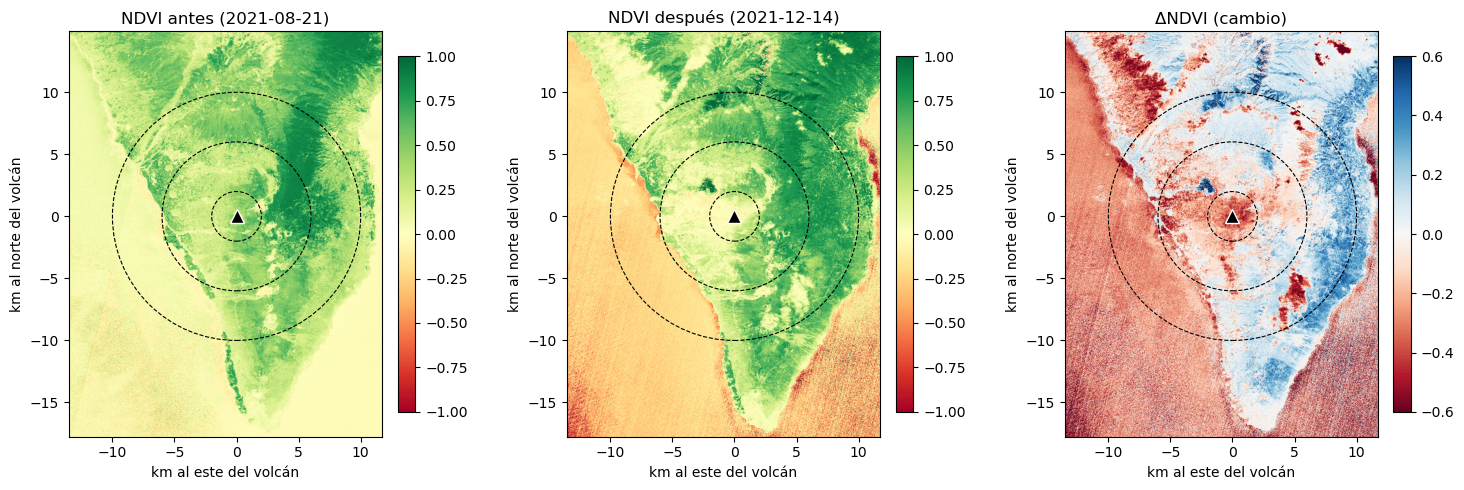

In [5]:
import matplotlib.pyplot as plt

# 📍 Posición del volcán de Tajogaite
cone_lon, cone_lat = -17.866, 28.613

# Fila y columna del cono en la imagen (la fila 0 es el borde norte del recuadro)
n_rows, n_cols = ndvi_before.shape
cone_row = int((bbox.max_y - cone_lat) / (bbox.max_y - bbox.min_y) * n_rows)
cone_col = int((cone_lon - bbox.min_x) / (bbox.max_x - bbox.min_x) * n_cols)

# Ejes en km con el volcán en (0, 0): [oeste, este, sur, norte]
km = resolution / 1000
extent = [-cone_col * km, (n_cols - cone_col) * km, -(n_rows - cone_row) * km, cone_row * km]

# Zonas de distancia al volcán (km): cono (0–2), coladas (2–6) y referencia (6–10)
rings = [0, 2, 6, 10]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# (imagen, título, paleta, mínimo, máximo)
panels = [
    (ndvi_before, f"NDVI antes ({time_before[0]})",  'RdYlGn', -1,   1),
    (ndvi_after,  f"NDVI después ({time_after[0]})", 'RdYlGn', -1,   1),
    (delta_ndvi,  "ΔNDVI (cambio)",                  'RdBu',   -0.6, 0.6),
]

for ax, (img, title, cmap, vmin, vmax) in zip(axs, panels):
    im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, extent=extent)
    ax.plot(0, 0, marker="^", markersize=10, color="black", markeredgecolor="white")  # volcán
    for r in rings[1:]:
        ax.add_patch(plt.Circle((0, 0), r, fill=False, color="black", linewidth=0.8, linestyle="--"))
    ax.set_title(title)
    ax.set_xlabel("km al este del volcán")
    ax.set_ylabel("km al norte del volcán")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 📏 6. Análisis: ¿hasta dónde llega el efecto del volcán?

Una erupción afecta la vegetación de distintas formas: la **lava** destruye todo por donde corre, la **ceniza** cubre la vegetación (más gruesa cerca del cono y más fina lejos, según el viento) y los **gases** pueden secarla. Todos estos efectos disminuyen con la distancia al cono. Vamos a medirlo:

1. Un píxel **tenía vegetación** si su NDVI antes de la erupción era mayor que 0,3, y la **perdió** si además su ΔNDVI es menor que -0,3. Lo escribimos como dos **máscaras** (en el código, `veg` y `loss`), que valen 1 (verdadero) o 0 (falso) en cada píxel $i$:

   $$\text{veg}_i = \left(\text{NDVI}_{\text{antes},\,i} > 0{,}3\right) \qquad\qquad \text{pérdida}_i = \text{veg}_i \ \text{ y } \ \left(\Delta\text{NDVI}_i < -0{,}3\right)$$

   Como valen 1 o 0, **contar píxeles es sumar la máscara**: $N_{\text{perdidos}} = \sum_{i \in \text{zona}} \text{pérdida}_i$ (en el código, `(loss & ring).sum()`).
2. Calculamos la **distancia** de cada píxel al volcán de Tajogaite, el cono de la erupción (-17,866; 28,613), y agrupamos los píxeles en tres zonas:
   - **0–2 km**: alrededor del cono (lava, ceniza gruesa y gases). Elegimos 2 km porque, mirando anillos más finos, la pérdida es casi total cerca del cono y se estabiliza a partir de esa distancia.
   - **2–6 km**: la zona por donde bajaron las coladas de lava hasta la costa, a unos 6 km al oeste del volcán (se ve en el mapa de ΔNDVI de la sección 5).
   - **6–10 km**: más lejos del volcán. Sirve de **referencia** para ver cuánto cambia la vegetación sin el efecto directo de la erupción.
3. En cada zona calculamos qué porcentaje de la vegetación se perdió y cuántas hectáreas representa (cada píxel = 0,09 ha, como vimos en la sección 3):

$$\%\ \text{perdido} = \frac{N_{\text{perdidos}}}{N_{\text{con vegetación}}} \times 100 \qquad\qquad \text{Superficie perdida} = N_{\text{perdidos}} \times 0{,}09\ \text{ha}$$

Preguntas para pensar:
- Compará el % perdido en cada zona con el de la zona de referencia: ¿cuántas veces mayor es? Lo que supera a la referencia es el efecto del volcán.
- La zona de referencia no llega a 0. ¿Qué cambios explican esa pérdida que no tiene que ver con la erupción?
- ¿Cuántas hectáreas se perdieron entre 0 y 6 km? Compará con las **1.219 ha** que cubrió la lava según los datos oficiales: ¿por qué tu cifra es mayor?

Distancia    Vegetación    Perdida    % perdido
 0–2  km        858 ha      462 ha     53.8 %
 2–6  km      5,669 ha      800 ha     14.1 %
 6–10 km     11,193 ha      839 ha      7.5 %


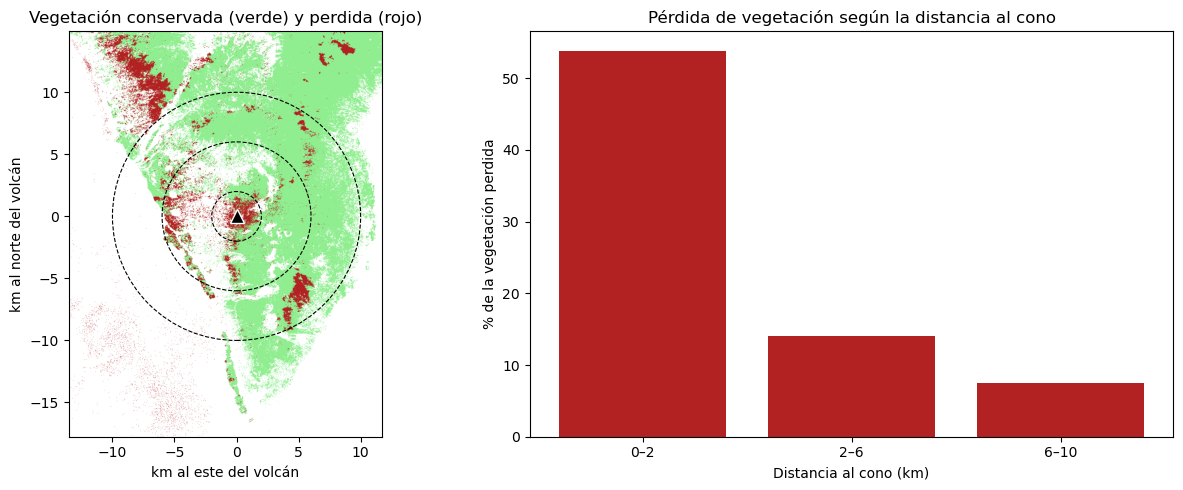

In [6]:
import numpy as np
from matplotlib.colors import ListedColormap

# Distancia de cada píxel al cono, en km (cada píxel mide `resolution` metros)
rows, cols = np.indices(ndvi_before.shape)
dist_km = np.hypot(rows - cone_row, cols - cone_col) * resolution / 1000

# Píxeles que tenían vegetación y píxeles que la perdieron
veg = ndvi_before > 0.3
loss = veg & (delta_ndvi < -0.3)
ha_pixel = (resolution / 100) ** 2   # 30 m -> 0,09 ha

# Porcentaje y superficie perdida en las zonas definidas en la sección 5
labels, pct = [], []
print("Distancia    Vegetación    Perdida    % perdido")
for a, b in zip(rings[:-1], rings[1:]):
    ring = (dist_km >= a) & (dist_km < b)
    ha_veg = (veg & ring).sum() * ha_pixel
    ha_loss = (loss & ring).sum() * ha_pixel
    labels.append(f"{a}–{b}")
    pct.append(ha_loss / ha_veg * 100)
    print(f"{a:>2}–{b:<2} km   {ha_veg:>8,.0f} ha   {ha_loss:>6,.0f} ha   {pct[-1]:6.1f} %")

# Mapa de los píxeles que entran en el cálculo: 0 = sin vegetación antes, 1 = vegetación conservada, 2 = vegetación perdida
clases = np.where(loss, 2, np.where(veg, 1, 0))

fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(13, 5))

ax_map.imshow(clases, cmap=ListedColormap(["white", "lightgreen", "firebrick"]), vmin=0, vmax=2, extent=extent)
ax_map.plot(0, 0, marker="^", markersize=10, color="black", markeredgecolor="white")  # volcán
for r in rings[1:]:
    ax_map.add_patch(plt.Circle((0, 0), r, fill=False, color="black", linewidth=0.8, linestyle="--"))
ax_map.set_title("Vegetación conservada (verde) y perdida (rojo)")
ax_map.set_xlabel("km al este del volcán")
ax_map.set_ylabel("km al norte del volcán")

ax_bar.bar(labels, pct, color="firebrick")
ax_bar.set_xlabel("Distancia al cono (km)")
ax_bar.set_ylabel("% de la vegetación perdida")
ax_bar.set_title("Pérdida de vegetación según la distancia al cono")

plt.tight_layout()
plt.show()

<details>
<summary><b>Ver respuestas</b> (intentá responder antes de abrir)</summary>

Los números corresponden a las imágenes del 21 de agosto y el 14 de diciembre de 2021.

**1. ¿Cuántas veces mayor es la pérdida que en la zona de referencia?**

- **0–2 km:** 53,8 % frente a 7,5 % → unas **7 veces** más. Alrededor del cono, la erupción arrasó con casi todo.
- **2–6 km:** 14,1 % frente a 7,5 % → casi **2 veces** más. El efecto se nota, pero es menor: la lava corrió por una franja angosta (se ve en el mapa de la izquierda), así que la mayor parte de la vegetación de esa zona no fue alcanzada.

**2. ¿Por qué la zona de referencia no llega a 0?**

Entre agosto y diciembre la vegetación también cambia por causas que no son la erupción: cultivos cosechados, pastos que se secan, nubes o sombras en alguna de las dos imágenes y pequeños errores de medición. Además, la ceniza fina puede llegar más lejos con el viento: la mancha roja al sudeste del volcán (en el mapa de la izquierda) cae dentro de la zona de referencia. Por eso ese ~7,5 % es una estimación aproximada del cambio "normal" del período.

**3. ¿Cuántas hectáreas se perdieron entre 0 y 6 km y por qué no coinciden con las 1.219 ha de lava?**

Se perdieron 462 + 800 = **1.262 ha**. Pero no todo es efecto del volcán:

- Si en esas zonas se hubiera perdido solo el 7,5 % "normal" de la referencia, se habrían perdido igual unas **490 ha** (el 7,5 % de las 6.527 ha con vegetación).
- Entonces, lo atribuible a la erupción es aproximadamente 1.262 − 490 ≈ **770 ha**.

Ese valor es **menor** que las 1.219 ha de lava, y tiene sentido: el mapa muestra que buena parte de la lava cayó sobre terreno que en agosto no tenía vegetación (NDVI ≤ 0,3: casas, caminos, suelo seco). Esos píxeles quedan en blanco y no se cuentan. Al mismo tiempo, la ceniza y los gases dañaron vegetación fuera de las coladas, y eso sí se cuenta.

Conclusión: el NDVI mide **pérdida de vegetación**, no superficie cubierta por lava. Son dos cosas relacionadas, pero distintas.

El mismo método sirve para estudiar otros eventos, como incendios, sequías o deforestación: basta con cambiar las coordenadas y las fechas.

</details>

## 📈 7. Evolución

Una erupción en la dorsal volcánica Cumbre Vieja, que comprende la mitad sur de la isla española de La Palma en las Islas Canarias, tuvo lugar entre el 19 de septiembre y el 13 de diciembre de 2021.

En esta sección seguimos la vegetación **mes a mes**, de agosto a diciembre de 2021, en un recuadro más chico, centrado en el volcán y las coladas. Septiembre se divide en dos: **antes** y **después** del inicio de la erupción (19 de septiembre).

Durante la erupción, las nubes y la **pluma** del volcán (la columna de ceniza y gases) taparon la zona en casi todas las pasadas del satélite: ninguna fecha de noviembre está despejada. Por eso armamos un **compuesto mensual**:

1. Descargamos todas las imágenes del mes, cada una con la banda **SCL** (*Scene Classification Layer*), que clasifica cada píxel.
2. En cada imagen descartamos los píxeles con **nubes, sombras de nubes o sin datos** (la misma idea de máscara de la sección 6).
3. En cada píxel calculamos la **mediana** del NDVI de las fechas en que estaba despejado.

Los píxeles que no estuvieron despejados en **ninguna** fecha del mes quedan **en gris** en los mapas. Las imágenes de esta sección se guardan en `data/evolucion/`.


In [7]:
import warnings

# 🗺️ Zona centrada en el volcán y las coladas, hasta la costa oeste
bbox_zoom = BBox(
    bbox=[-17.94, 28.57, -17.84, 28.65],
    crs=CRS.WGS84
)
DATA_ZOOM = "./data/evolucion"

# Clases SCL que descartamos: 0 = sin datos, 3 = sombra de nube, 8 y 9 = nubes, 10 = cirros
SCL_DESCARTAR = [0, 3, 8, 9, 10]

def get_image_scl(date, bbox):
    """Descarga B04, B08 y SCL de una fecha para el recuadro."""
    request = SentinelHubRequest(
        data_folder=DATA_ZOOM,
        evalscript="""
        //VERSION=3
        function setup() {
          return {
            input: ["B04", "B08", "SCL"],
            output: { bands: 3, sampleType: "FLOAT32" }
          };
        }
        function evaluatePixel(sample) {
          return [sample.B04, sample.B08, sample.SCL];
        }
        """,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=S2_L2A,
                time_interval=(date, date),
                mosaicking_order='leastCC'
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=bbox_to_dimensions(bbox, resolution=resolution),
        config=config
    )
    return request.get_data(save_data=True)[0]

def monthly_composite(bbox, time_interval):
    """NDVI compuesto del mes: en cada píxel, la mediana de las fechas en que estaba despejado."""
    results = catalog.search(S2_L2A, bbox=bbox, time=time_interval,
                             fields={"include": ["properties.datetime"], "exclude": []}, limit=50)
    dates = sorted({r["properties"]["datetime"][:10] for r in results})

    ndvis = []
    for date in dates:
        img = get_image_scl(date, bbox)
        b4, b8, scl = img[..., 0], img[..., 1], img[..., 2]
        valid = ~np.isin(scl, SCL_DESCARTAR)
        ndvis.append(np.where(valid, ndvi(b8, b4), np.nan))   # NaN = píxel descartado
    stack = np.stack(ndvis)

    with warnings.catch_warnings():                   # evita el aviso de los píxeles sin ninguna fecha válida
        warnings.simplefilter("ignore", RuntimeWarning)
        composite = np.nanmedian(stack, axis=0)

    sin_dato = np.isnan(composite).mean() * 100
    print(f"🛰️ {time_interval[0]} a {time_interval[1]}: {len(dates)} fechas · píxeles sin ninguna fecha despejada: {sin_dato:4.1f} %")
    return composite

# 🔍 Compuesto de cada período (la erupción empezó el 19 de septiembre)
months = {
    "Ago":           ("2021-08-01", "2021-08-31"),
    "Sep (antes)":   ("2021-09-01", "2021-09-18"),
    "Sep (después)": ("2021-09-19", "2021-09-30"),
    "Oct":           ("2021-10-01", "2021-10-31"),
    "Nov":           ("2021-11-01", "2021-11-30"),
    "Dic":           ("2021-12-01", "2021-12-31"),
}
images = {label: monthly_composite(bbox_zoom, interval) for label, interval in months.items()}

🛰️ 2021-08-01 a 2021-08-31: 7 fechas · píxeles sin ninguna fecha despejada:  0.0 %
🛰️ 2021-09-01 a 2021-09-18: 3 fechas · píxeles sin ninguna fecha despejada:  0.0 %
🛰️ 2021-09-19 a 2021-09-30: 3 fechas · píxeles sin ninguna fecha despejada: 12.9 %
🛰️ 2021-10-01 a 2021-10-31: 6 fechas · píxeles sin ninguna fecha despejada:  1.8 %
🛰️ 2021-11-01 a 2021-11-30: 6 fechas · píxeles sin ninguna fecha despejada: 32.5 %
🛰️ 2021-12-01 a 2021-12-31: 6 fechas · píxeles sin ninguna fecha despejada:  4.0 %


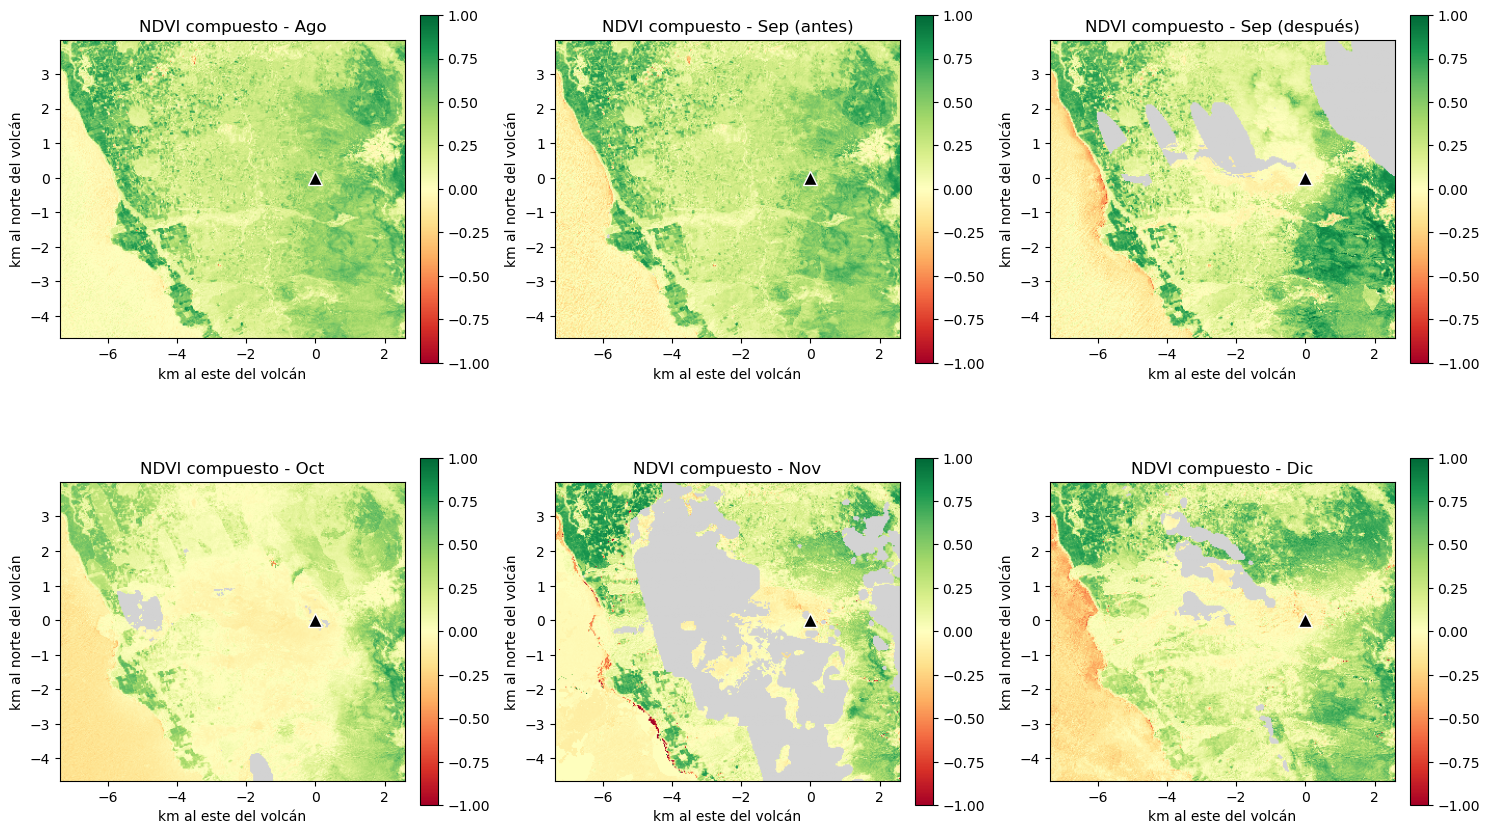

In [8]:
# --- Ejes en km con el volcán en (0, 0), como en la sección 5 ---
n_rows_9, n_cols_9 = images["Ago"].shape
row_9 = (bbox_zoom.max_y - cone_lat) / (bbox_zoom.max_y - bbox_zoom.min_y) * n_rows_9
col_9 = (cone_lon - bbox_zoom.min_x) / (bbox_zoom.max_x - bbox_zoom.min_x) * n_cols_9
extent_9 = [-col_9 * km, (n_cols_9 - col_9) * km, -(n_rows_9 - row_9) * km, row_9 * km]

# Misma paleta que en la sección 5; los píxeles sin ninguna fecha despejada (NaN) en gris
cmap_ndvi = plt.get_cmap("RdYlGn").copy()
cmap_ndvi.set_bad("lightgrey")

# --- NDVI compuesto de cada período ---
fig, axs = plt.subplots(2, 3, figsize=(15, 9))
for ax, (label, img) in zip(axs.ravel(), images.items()):
    im = ax.imshow(img, cmap=cmap_ndvi, vmin=-1, vmax=1, extent=extent_9)
    ax.plot(0, 0, marker="^", markersize=10, color="black", markeredgecolor="white")  # volcán
    ax.set_title(f"NDVI compuesto - {label}")
    ax.set_xlabel("km al este del volcán")
    ax.set_ylabel("km al norte del volcán")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()